**Scenario:**
A healthcare organisation wants to develop a diagnostic tool to predict whether a patient has diabetes based on various health metrics. Your task is to implement an Artificial Neural Network (ANN) to create an accurate prediction model that can assist healthcare providers in early diagnosis.

**Assignment Instructions:**
Create a Python notebook to construct, train, and evaluate an artificial neural network for diabetes prediction. This assignment will integrate supervised learning concepts with practical healthcare applications while exploring the capabilities of neural networks.

**Dataset**

The enhanced_diabetes_dataset.csv Download enhanced_diabetes_dataset.csvcontains health information for female patients of Pima Indian heritage, including:

**Pregnancies:** Number of times pregnant

**Glucose:** Plasma glucose concentration (mg/dL)

**BloodPressure:** Diastolic blood pressure (mm Hg)

**SkinThickness:** Triceps skin fold thickness (mm)

**Insulin:** 2-Hour serum insulin (mu U/ml)

**BMI:** Body mass index (weight in kg/(height in m)²)

**DiabetesPedigreeFunction:** Diabetes pedigree function (a function which scores likelihood of diabetes based on family history)

**Age:** Age in years

**Outcome:** Class variable (0 or 1) indicating whether the patient has diabetes (1) or not (0)


---



**Task 1:** Correctly import the dataset and show basic information and statistics
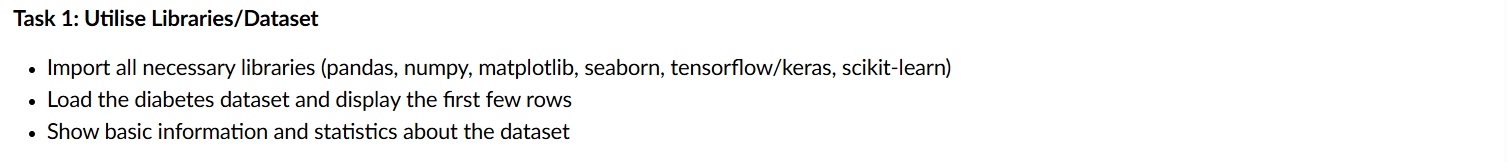

In [1]:
# Task 1, Activity 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as ssc
from sklearn.metrics import classification_report as crp
from sklearn.metrics import confusion_matrix as cmt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Task 1 - Activity 2 - Load the diabetes dataset and display the first few rows
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Only access a specific project folder
project_path = '/content/drive/My Drive/Colab Notebooks/NUS_GenAI_Lab/lab_data'

enhanced_diabetes_dataset = f'{project_path}/enhanced_diabetes_dataset.csv'

try:
    # Read the data from CSV file
    df = pd.read_csv(enhanced_diabetes_dataset)
    print("Successfully loaded data from enhanced_diabetes_dataset.csv")

except FileNotFoundError:
    print("enhanced_diabetes_dataset.csv file not found.")

# Display the first few rows of the dataset
print("\nFirst 5 rows of the enhanced diabetes dataset dataset:")
print(df.head())
print("record")
print(df['Diabetes'].value_counts())

Mounted at /content/drive
Successfully loaded data from enhanced_diabetes_dataset.csv

First 5 rows of the enhanced diabetes dataset dataset:
   Age  Gender  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0   52       1            1      124           95.0           20.0        0   
1   43       1            2      144           86.0           23.0        3   
2   55       1            4      141          113.0           18.0      297   
3   68       1            3      125          110.0           32.0      210   
4   41       0            0      177           92.0           14.0      189   

    BMI  DiabetesPedigreeFunction  HbA1c  FastingBS  Triglycerides   HDL  \
0  36.0                     0.078    4.7         87          142.0  37.0   
1  32.9                     0.118    6.3        135          162.0  89.0   
2  43.4                     0.139    5.4        113          180.0  45.0   
3  22.7                     0.197    5.2         93          262.0  56.0   
4  

In [3]:
#Show basic information and statistics about the dataset
print("\nDataset information:")
print(df.info())

# Display summary statistics
print("\nSummary statistics:")
print(df.describe())

# Optional: Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2000 non-null   int64  
 1   Gender                    2000 non-null   int64  
 2   Pregnancies               2000 non-null   int64  
 3   Glucose                   2000 non-null   int64  
 4   BloodPressure             1902 non-null   float64
 5   SkinThickness             1914 non-null   float64
 6   Insulin                   2000 non-null   int64  
 7   BMI                       2000 non-null   float64
 8   DiabetesPedigreeFunction  2000 non-null   float64
 9   HbA1c                     2000 non-null   float64
 10  FastingBS                 2000 non-null   int64  
 11  Triglycerides             1909 non-null   float64
 12  HDL                       1904 non-null   float64
 13  Smoking                   2000 non-null  

**Task 2:** Generate at least 3 EDA visualisations based on the dataset
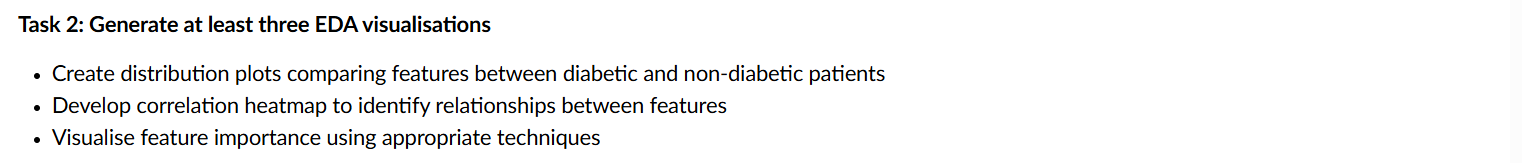

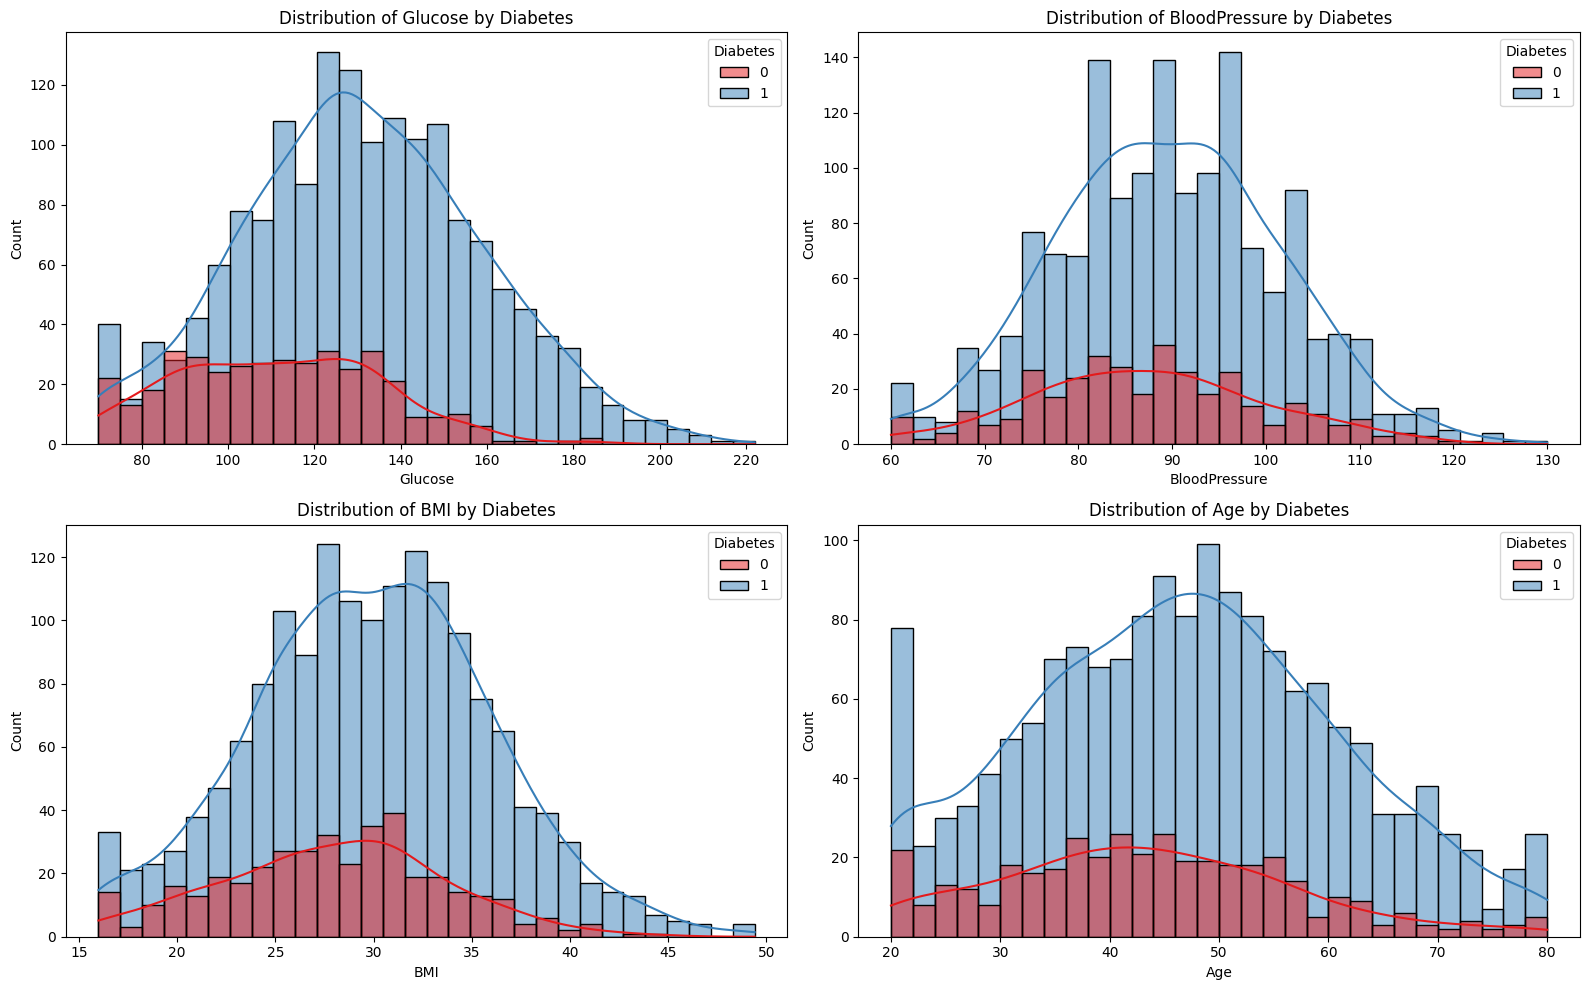

In [4]:
# Task 2 - Activity 1: Distribution plots for key features by diabetes outcome

features = ['Glucose', 'BloodPressure', 'BMI', 'Age']

plt.figure(figsize=(16, 10))

for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=col, hue='Diabetes', kde=True, palette='Set1', bins=30)
    plt.title(f'Distribution of {col} by Diabetes')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


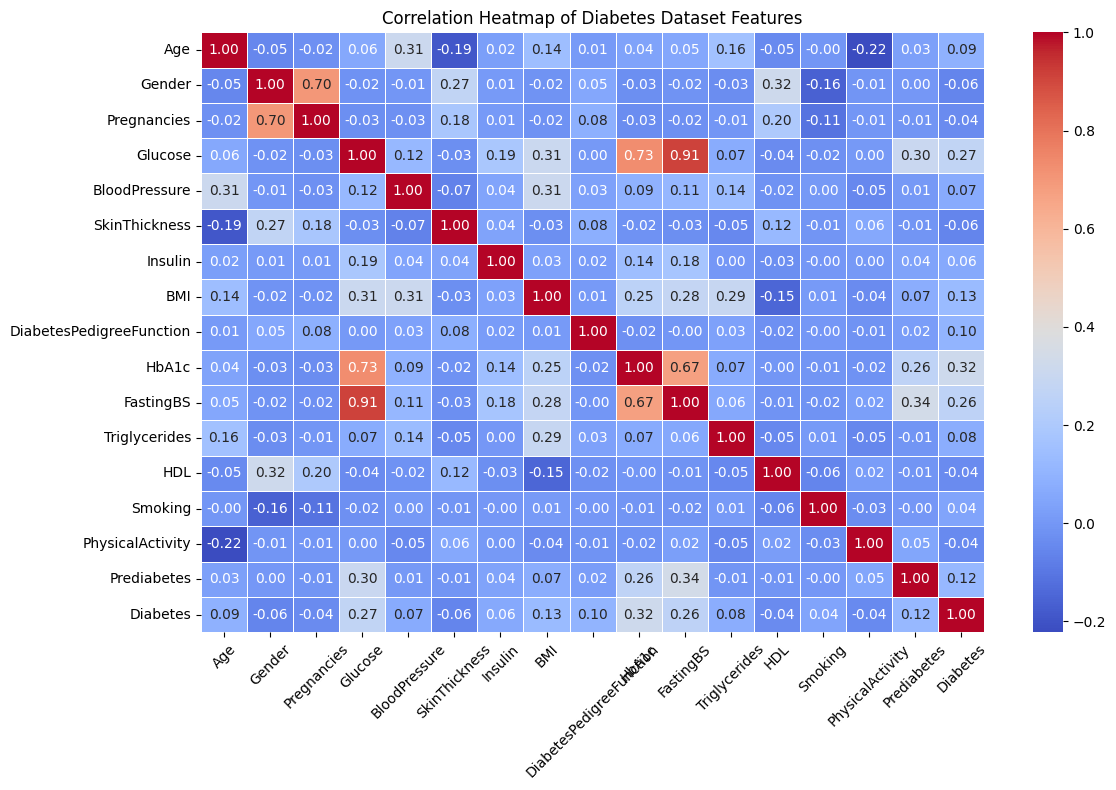

In [5]:
# Task 2 - Activity 2: Develop correlation heatmap to identify relationships between features

# Compute the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Set up the heatmap plot
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add titles
plt.title('Correlation Heatmap of Diabetes Dataset Features')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


--- Generating Feature Importance Visualizations ---


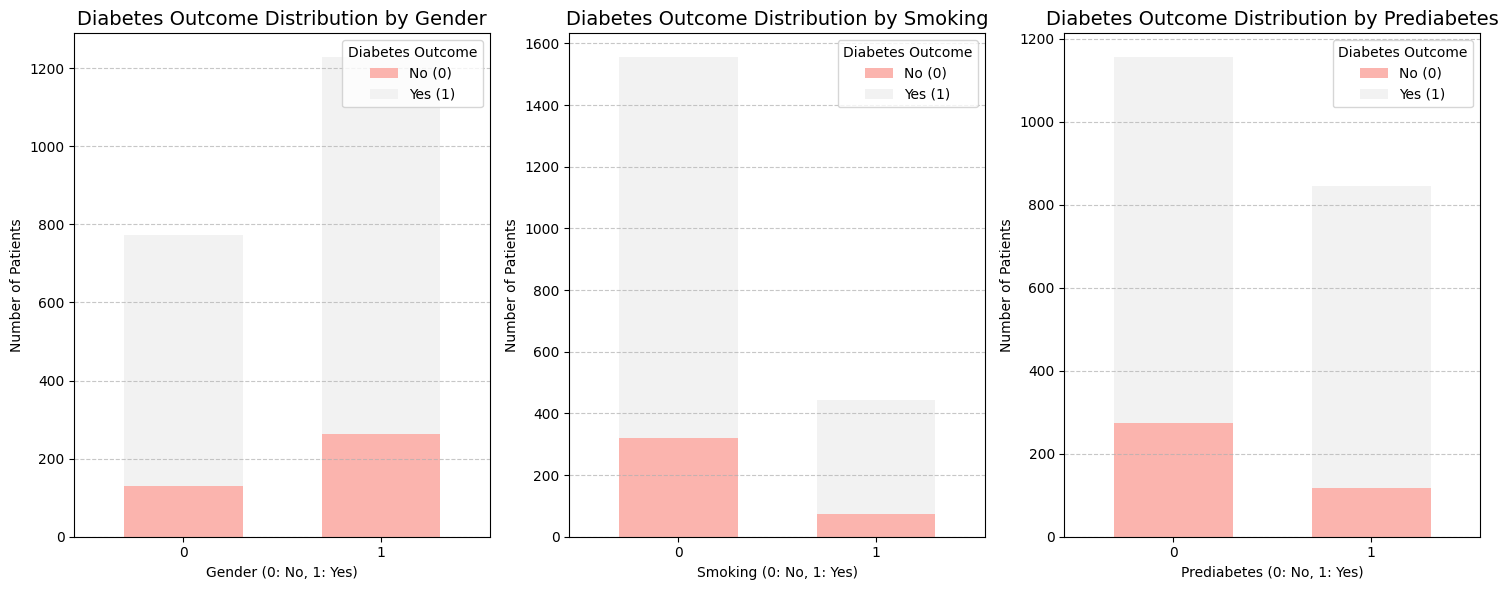

In [6]:
# Task 2 - Activity 3 - Visualise feature importance using appropriate techniques

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Generating Feature Importance Visualizations ---")

# Count Plots for selected categorical/binary features vs. Diabetes Outcome

binary_features = ['Gender', 'Smoking', 'Prediabetes'] # Assuming these are 0/1 encoded

plt.figure(figsize=(15, 6)) # Adjust figure size

for i, feature in enumerate(binary_features):
    plt.subplot(1, len(binary_features), i + 1)
    ct = pd.crosstab(df[feature], df['Diabetes'])
    ct.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='Pastel1', width=0.6) # Use ax=plt.gca() for subplot
    plt.title(f'Diabetes Outcome Distribution by {feature}', fontsize=14)
    plt.xlabel(f'{feature} (0: No, 1: Yes)')
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=0)
    plt.legend(title='Diabetes Outcome', labels=['No (0)', 'Yes (1)'], loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Task 3:** Check for missing values and outliers
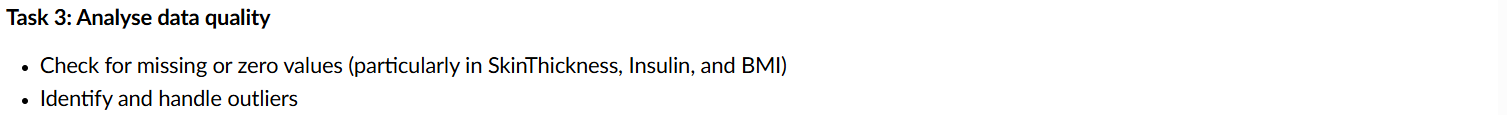

In [7]:
#Task 3 - Activity 1 - Check for missing or zero values (particularly in SkinThickness, Insulin, and BMI)

print("--- Checking for Missing and Zero Values ---")

print("\nNumber of NaN (Not a Number) missing values per column:")
print(df.isnull().sum())

columns_with_potential_zeros_as_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in columns_with_potential_zeros_as_missing:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

--- Checking for Missing and Zero Values ---

Number of NaN (Not a Number) missing values per column:
Age                           0
Gender                        0
Pregnancies                   0
Glucose                       0
BloodPressure                98
SkinThickness                86
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
HbA1c                         0
FastingBS                     0
Triglycerides                91
HDL                          96
Smoking                       0
PhysicalActivity            101
Prediabetes                   0
Diabetes                      0
dtype: int64
Glucose: 0 zero values
BloodPressure: 0 zero values
SkinThickness: 0 zero values
Insulin: 737 zero values
BMI: 0 zero values


In [8]:
# Task 3 - Activity 2 - Identify and handle outliers

import numpy as np # Ensure numpy is imported if not already in context
import pandas as pd # Ensure pandas is imported if not already in context
# Assuming 'df' DataFrame is loaded from previous steps

print("--- Identifying and Handling Outliers ---")

# Define numerical features for outlier detection.

numerical_features_for_outliers = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
    'BMI', 'DiabetesPedigreeFunction', 'Age', 'HbA1c', 'FastingBS',
    'Triglycerides', 'HDL', 'PhysicalActivity'
]

print(f"\nAnalyzing and handling outliers in the following numerical features: {numerical_features_for_outliers}")

# Create a copy of the DataFrame to store the data with handled outliers
# This prevents modifying the original 'df' for later use.
df_processed_outliers = df.copy()

# Store counts of identified outliers for reporting
outliers_found_count = {}

# --- Outlier Handling Strategy: Capping using IQR method ---
# Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR will be capped.
for col in numerical_features_for_outliers:
    Q1 = df_processed_outliers[col].quantile(0.25)
    Q3 = df_processed_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers_lower = df_processed_outliers[df_processed_outliers[col] < lower_bound]
    outliers_upper = df_processed_outliers[df_processed_outliers[col] > upper_bound]

    total_outliers_in_col = len(outliers_lower) + len(outliers_upper)
    outliers_found_count[col] = total_outliers_in_col

    if total_outliers_in_col > 0:
        print(f"'{col}': {total_outliers_in_col} outliers identified (Lower: {len(outliers_lower)}, Upper: {len(outliers_upper)}). Capping values...")
        # Cap values
        df_processed_outliers[col] = np.where(df_processed_outliers[col] < lower_bound, lower_bound, df_processed_outliers[col])
        df_processed_outliers[col] = np.where(df_processed_outliers[col] > upper_bound, upper_bound, df_processed_outliers[col])
    else:
        print(f"'{col}': No outliers identified using IQR method for capping.")

for col, count in outliers_found_count.items():
    if count > 0:
        print(f"- {col}: {count}")
if not any(outliers_found_count.values()):
    print("No outliers were capped in the specified features.")

print("Displaying head of the processed DataFrame:")
print(df_processed_outliers.head())


--- Identifying and Handling Outliers ---

Analyzing and handling outliers in the following numerical features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'HbA1c', 'FastingBS', 'Triglycerides', 'HDL', 'PhysicalActivity']
'Pregnancies': 6 outliers identified (Lower: 0, Upper: 6). Capping values...
'Glucose': 6 outliers identified (Lower: 0, Upper: 6). Capping values...
'BloodPressure': 6 outliers identified (Lower: 0, Upper: 6). Capping values...
'SkinThickness': 9 outliers identified (Lower: 0, Upper: 9). Capping values...
'Insulin': 1 outliers identified (Lower: 0, Upper: 1). Capping values...
'BMI': 8 outliers identified (Lower: 0, Upper: 8). Capping values...
'DiabetesPedigreeFunction': 106 outliers identified (Lower: 0, Upper: 106). Capping values...
'Age': No outliers identified using IQR method for capping.
'HbA1c': 5 outliers identified (Lower: 0, Upper: 5). Capping values...
'FastingBS': 8 outliers identifie

**Task 4:** Prepare features and target variables
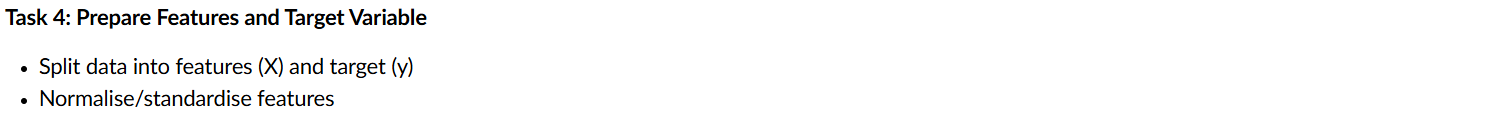

--- Splitting Data into Features (X) and Target (y) ---

--- Visualizing Target Variable Distribution ---


/tmp/ipython-input-10-3048036560.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


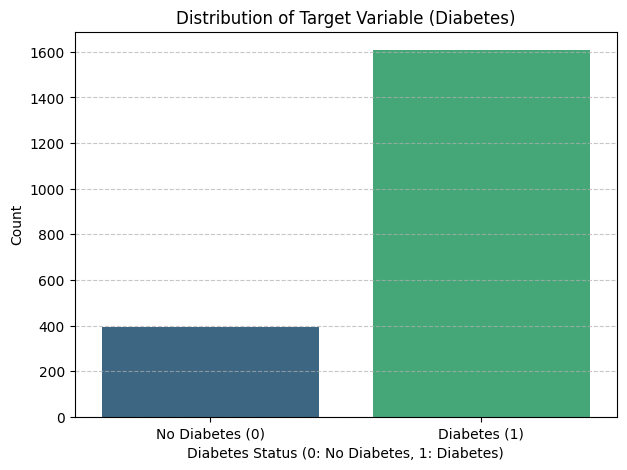


Bar graph showing the distribution of diabetes cases generated.


In [10]:
#Task 4 - Activity 1 - Split data into features (X) and target (y)

print("--- Splitting Data into Features (X) and Target (y) ---")


print("\n--- Visualizing Target Variable Distribution ---")

plt.figure(figsize=(7, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Target Variable (Diabetes)')
plt.xlabel('Diabetes Status (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Diabetes (0)', 'Diabetes (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nBar graph showing the distribution of diabetes cases generated.")


In [12]:
#Task 4 - Activity 2 - Normalise/standardise features
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("--- Normalising/Standardising Features using StandardScaler ---")

# We will split into 70% train, 15% validation, 15% test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=(0.15/0.70), random_state=42, stratify=y_train_full) # 15% of total data

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the scaler fitted on the training data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

print("\nFirst 5 rows of X_train_scaled (example):")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

print("\nFeatures successfully normalised/standardised.")

# IMPORTANT: Update your X_train, X_val, X_test variables to use the scaled versions
X_train = X_train_scaled
X_val = X_val_scaled
X_test = X_test_scaled

--- Normalising/Standardising Features using StandardScaler ---
X_train_scaled shape: (1100, 16)
X_val_scaled shape: (300, 16)
X_test_scaled shape: (600, 16)

First 5 rows of X_train_scaled (example):
        Age    Gender  Pregnancies   Glucose  BloodPressure  SkinThickness  \
0 -0.695838  0.813407    -0.318460 -0.152845       0.724994       0.591398   
1 -1.330049  0.813407     0.806118 -0.047313      -0.512165       1.160993   
2 -0.413967 -1.229396    -0.880749  0.585877       0.312608      -0.661711   
3 -0.836774 -1.229396    -0.880749  0.796941      -0.347210       0.591398   
4 -0.695838  0.813407     0.806118 -0.223200      -1.007028       0.249641   

    Insulin       BMI  DiabetesPedigreeFunction     HbA1c  FastingBS  \
0 -0.303502  0.096537                 -0.816642 -0.618474   1.123828   
1 -0.948137 -0.393347                  0.607447  0.358628   0.263795   
2  1.329573  0.766045                 -0.916198  0.875917   0.521805   
3 -0.664497  1.451883                  0.0

**Task 5:** Handle class imbalance and split into training, validation and test datasets
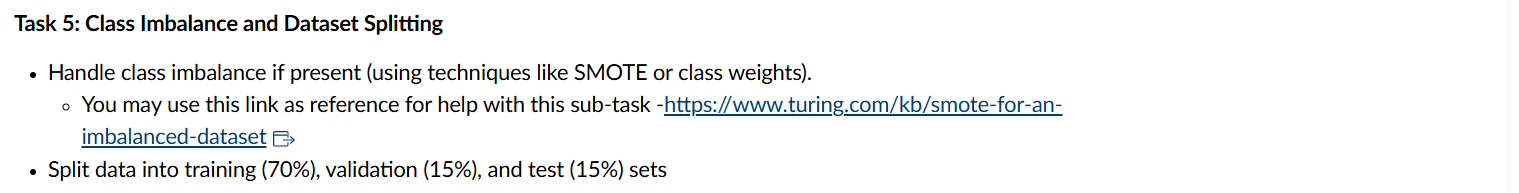

In [14]:
# Task 5 - Activity 1 - Handle class imbalance if present (using techniques like SMOTE)


from collections import Counter
from imblearn.over_sampling import SMOTE


print("--- Checking and Handling Class Imbalance ---")

print("\nClass distribution in original y_train:")
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True))

# Determine if imbalance is significant enough to warrant SMOTE
minority_class_count = pd.Series(y_train).value_counts()[1] if 1 in pd.Series(y_train).value_counts() else 0
majority_class_count = pd.Series(y_train).value_counts()[0] if 0 in pd.Series(y_train).value_counts() else 0

if minority_class_count == 0:
    print("\nNo minority class found in y_train. Skipping SMOTE.")
elif majority_class_count == 0:
    print("\nNo majority class found in y_train. Skipping SMOTE.")
elif minority_class_count / majority_class_count < 0.5: # Example threshold
    print("\nSignificant class imbalance detected. Applying SMOTE to the training data...")

# Apply SMOTE to balance the training data
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print("\nClass distribution in y_train after SMOTE:")
    print(pd.Series(y_train_res).value_counts())
    print(pd.Series(y_train_res).value_counts(normalize=True))

    print("\nSMOTE successfully applied. Training data is now balanced.")
    # Update X_train and y_train to the resampled versions for subsequent steps
    X_train = X_train_res
    y_train = y_train_res

else:
    print("\nClass imbalance is not significant enough to warrant SMOTE based on heuristic (minority class >= 50% of majority).")
    print("Proceeding with original X_train and y_train.")

print("\nShape of X_train after imbalance handling:", X_train.shape)
print("Shape of y_train after imbalance handling:", y_train.shape)
print("Note: The test set (X_test, y_test) remains untouched.")

--- Checking and Handling Class Imbalance ---

Class distribution in original y_train:
Diabetes
1    885
0    215
Name: count, dtype: int64
Diabetes
1    0.804545
0    0.195455
Name: proportion, dtype: float64

Class imbalance is not significant enough to warrant SMOTE based on heuristic (minority class >= 50% of majority).
Proceeding with original X_train and y_train.

Shape of X_train after imbalance handling: (1100, 16)
Shape of y_train after imbalance handling: (1100,)
Note: The test set (X_test, y_test) remains untouched.


In [15]:
# Task 5 - Activity 2 -Split data into training (70%), validation (15%), and test (15%) sets

print("--- Splitting Data into Training, Validation, and Test Sets (70%-15%-15%) ---")

# Step 1: Split the data into 70% for training and 30% for a temporary set (which will be further split)
X_train, X_temp, y_train, y_temp = tts(X, y, test_size=0.30, random_state=42, stratify=y)

# Step 2: Split the 30% temporary set into two equal halves (15% for validation, 15% for test)
X_val, X_test, y_val, y_test = tts(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Original dataset shape (X): {X.shape}")
print(f"Original dataset shape (y): {y.shape}")

print(f"\n--- Resulting Set Shapes ---")
print(f"Training set (70%): X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Validation set (15%): X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Test set (15%): X_test: {X_test.shape}, y_test: {y_test.shape}")

# Verify the distribution of the target variable across all sets to ensure stratification worked
print("\n--- Diabetes Outcome Distribution (Normalized) ---")
print(f"Original:   \n{y.value_counts(normalize=True).round(3)}")
print(f"Training:   \n{y_train.value_counts(normalize=True).round(3)}")
print(f"Validation: \n{y_val.value_counts(normalize=True).round(3)}")
print(f"Test:       \n{y_test.value_counts(normalize=True).round(3)}")

print("\nData successfully split into training, validation, and test sets.")

--- Splitting Data into Training, Validation, and Test Sets (70%-15%-15%) ---
Original dataset shape (X): (2000, 16)
Original dataset shape (y): (2000,)

--- Resulting Set Shapes ---
Training set (70%): X_train: (1400, 16), y_train: (1400,)
Validation set (15%): X_val: (300, 16), y_val: (300,)
Test set (15%): X_test: (300, 16), y_test: (300,)

--- Diabetes Outcome Distribution (Normalized) ---
Original:   
Diabetes
1    0.804
0    0.196
Name: proportion, dtype: float64
Training:   
Diabetes
1    0.804
0    0.196
Name: proportion, dtype: float64
Validation: 
Diabetes
1    0.803
0    0.197
Name: proportion, dtype: float64
Test:       
Diabetes
1    0.803
0    0.197
Name: proportion, dtype: float64

Data successfully split into training, validation, and test sets.


**Task 6:** Design an appropriate DCNN architecture and select appropriate activation functions
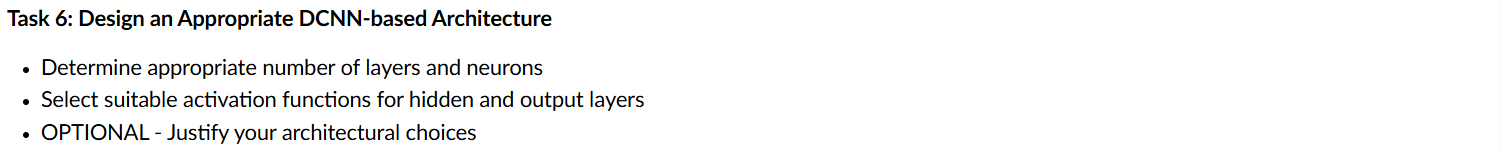

In [16]:
# Task 6, Activity 1: Determine appropriate number of layers and neurons



print("--- Designing the Artificial Neural Network (ANN) Architecture ---")

# Determine the number of input features from our training data
input_features = X_train.shape[1]
print(f"Number of input features (from X_train.shape[1]): {input_features}")

# Initialize the Sequential model (a linear stack of layers)
model = Sequential()

# Add the first hidden layer
# 'units' is the number of neurons
model.add(Dense(units=64, activation='relu', input_shape=(input_features,)))

# Add the second hidden layer
# Input shape is automatically inferred for subsequent layers
model.add(Dense(units=32, activation='relu'))

# Add the output layer
# 'units=1' for binary classification (predicting 0 or 1)
# 'activation="sigmoid"' to output a probability between 0 and 1
model.add(Dense(units=1, activation='sigmoid')) # This was the line with the error

# Display a summary of the model's architecture
print("\n--- ANN Model Summary ---")
model.summary()
print("\nArtificial Neural Network (ANN) architecture designed successfully!")

--- Designing the Artificial Neural Network (ANN) Architecture ---
Number of input features (from X_train.shape[1]): 16

--- ANN Model Summary ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


Artificial Neural Network (ANN) architecture designed successfully!


**Task 7:** Configure the training process, including appropriate loss function, evaluation metrics, optimiser and learning rate, and regularisation to prevent overfitting
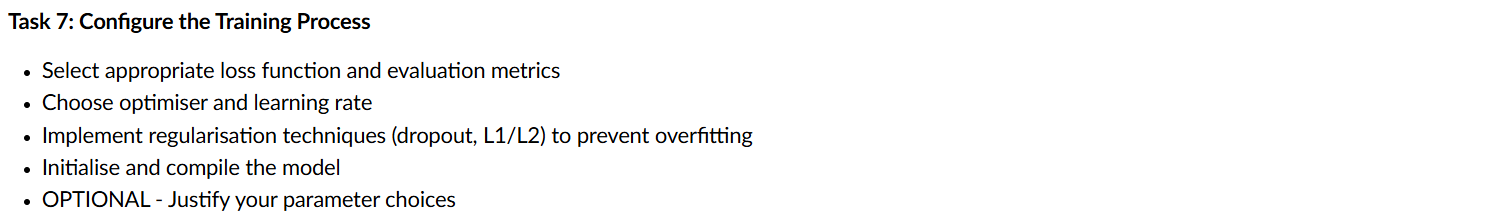

In [17]:
# Task 7, Activity 1 (Implementation): Compile the model with selected loss function and evaluation metrics
print("--- Compiling the ANN Model ---")

# Define the optimizer
optimizer_choice = 'adam'

# Define the loss function
loss_function_choice = 'binary_crossentropy'

# Define the evaluation metrics
metrics_list = [
    'accuracy', # Standard accuracy
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]

# Compile the model
model.compile(optimizer=optimizer_choice,
              loss=loss_function_choice,
              metrics=metrics_list)

print(f"Model compiled successfully with Optimizer: '{optimizer_choice}', Loss: '{loss_function_choice}', and Metrics: {metrics_list}")

--- Compiling the ANN Model ---
Model compiled successfully with Optimizer: 'adam', Loss: 'binary_crossentropy', and Metrics: ['accuracy', <Precision name=precision>, <Recall name=recall>, <AUC name=auc>]


In [18]:
# Task 7, Activity 2: Choose optimizer and learning rate

print("--- Choosing Optimizer and Learning Rate ---")
custom_learning_rate = 0.001 # You can experiment with this value
optimizer_custom = tf.keras.optimizers.Adam(learning_rate=custom_learning_rate)

print(f"Chosen Optimizer: Adam")
print(f"Using Learning Rate: {custom_learning_rate} (custom) or default (0.001) if not explicitly set.")

model.compile(optimizer=optimizer_custom, # Use the instantiated optimizer
              loss='binary_crossentropy',
              metrics=[
                  'accuracy',
                  tf.keras.metrics.Precision(name='precision'),
                  tf.keras.metrics.Recall(name='recall'),
                  tf.keras.metrics.AUC(name='auc')
              ])

print("\nModel re-compiled with the specified optimizer and learning rate.")

--- Choosing Optimizer and Learning Rate ---
Chosen Optimizer: Adam
Using Learning Rate: 0.001 (custom) or default (0.001) if not explicitly set.

Model re-compiled with the specified optimizer and learning rate.


In [19]:
# Task 7, Activity 3: Implement regularisation techniques (dropout, L1/L2) to prevent overfitting

print("Implementing Regularization Techniques (Dropout, L2)")

# Determine the number of input features (from X_train.shape[1])
input_features = X_train.shape[1]
print(f"Number of input features: {input_features}")

# Define regularization parameters
dropout_rate = 0.3  # Fraction of neurons to drop out (e.g., 20-50%)
l2_lambda = 0.001   # L2 regularization strength (small positive value)

print(f"Dropout Rate: {dropout_rate}")
print(f"L2 Regularization Lambda: {l2_lambda}")


# Re-initialize the Sequential model to include regularization
model = Sequential()

# Add the first hidden layer with L2 regularization
model.add(Dense(units=64, activation='relu', input_shape=(input_features,),
                kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)))
# Add a Dropout layer after the first hidden layer
model.add(tf.keras.layers.Dropout(dropout_rate))

# Add the second hidden layer with L2 regularization
model.add(Dense(units=32, activation='relu',
                kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)))
# Add a Dropout layer after the second hidden layer
model.add(tf.keras.layers.Dropout(dropout_rate))

# Add the output layer (no regularization typically needed here)
model.add(Dense(units=1, activation='sigmoid'))

# Display a summary of the new model's architecture
print("\n--- ANN Model Summary with Regularization ---")
model.summary()

# Re-compile the model with the chosen optimizer, loss, and metrics
# Using the custom Adam optimizer with specified learning rate from previous step
custom_learning_rate = 0.001
optimizer_custom = tf.keras.optimizers.Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer_custom,
              loss='binary_crossentropy',
              metrics=[
                  'accuracy',
                  tf.keras.metrics.Precision(name='precision'),
                  tf.keras.metrics.Recall(name='recall'),
                  tf.keras.metrics.AUC(name='auc')
              ])

print("\nANN model with regularization layers designed and compiled successfully!")

Implementing Regularization Techniques (Dropout, L2)
Number of input features: 16
Dropout Rate: 0.3
L2 Regularization Lambda: 0.001

--- ANN Model Summary with Regularization ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


ANN model with regularization layers designed and compiled successfully!


In [20]:
# Task 7, Activity 4: Initialise and compile the model

print("--- Initializing and Compiling the ANN Model (Reconfirming) ---")

# Determine the number of input features (from X_train.shape[1])
input_features = X_train.shape[1]
print(f"Number of input features: {input_features}")

# Define regularization parameters (as set in Task 7, Activity 3)
dropout_rate = 0.3
l2_lambda = 0.001

# Define optimizer and learning rate (as set in Task 7, Activity 2)
custom_learning_rate = 0.001
optimizer_custom = tf.keras.optimizers.Adam(learning_rate=custom_learning_rate)

# Define loss function and metrics (as set in Task 7, Activity 1)
loss_function_choice = 'binary_crossentropy'
metrics_list = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]

# --- Model Initialization (from Task 6 and updated in Task 7, Activity 3) ---
model = Sequential()
model.add(Dense(units=64, activation='relu', input_shape=(input_features,),
                kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)))
model.add(tf.keras.layers.Dropout(dropout_rate))
model.add(Dense(units=32, activation='relu',
                kernel_regularizer=tf.keras.regularizers.l2(l2_lambda)))
model.add(tf.keras.layers.Dropout(dropout_rate))
model.add(Dense(units=1, activation='sigmoid'))

# --- Model Compilation (from Task 7, Activities 1 & 2) ---
model.compile(optimizer=optimizer_custom,
              loss=loss_function_choice,
              metrics=metrics_list)

print("\n--- ANN Model Summary ---")
model.summary()

print("\nANN model has been successfully initialized and compiled.")
print("It is now ready for the training process.")

--- Initializing and Compiling the ANN Model (Reconfirming) ---
Number of input features: 16

--- ANN Model Summary ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


ANN model has been successfully initialized and compiled.
It is now ready for the training process.


**Task 8:** Train the model with the appropriate batch size and number of epochs
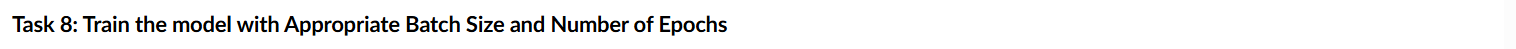

In [21]:
# Task 8: Train the model with Appropriate Batch Size and Number of Epochs

print("--- Training the Artificial Neural Network Model ---")

# Define training parameters
epochs = 100    # Number of full passes through the training dataset
batch_size = 32 # Number of samples per gradient update

print(f"Training for {epochs} epochs with a batch size of {batch_size}.")
print("Monitoring performance on the validation set during training.")

# Train the model
# The 'history' object will store training loss and metrics for each epoch
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val), # Use validation set to monitor performance
                    verbose=1) # Set to 1 to see progress bar and metrics per epoch

print("\nModel training complete!")

--- Training the Artificial Neural Network Model ---
Training for 100 epochs with a batch size of 32.
Monitoring performance on the validation set during training.
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2050 - auc: 0.0185 - loss: nan - precision: 0.7500 - recall: 0.0121 - val_accuracy: 0.1967 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1966 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1967 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1873 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1967 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1828 

***Task 9:*** Implement callbacks to improve the training process
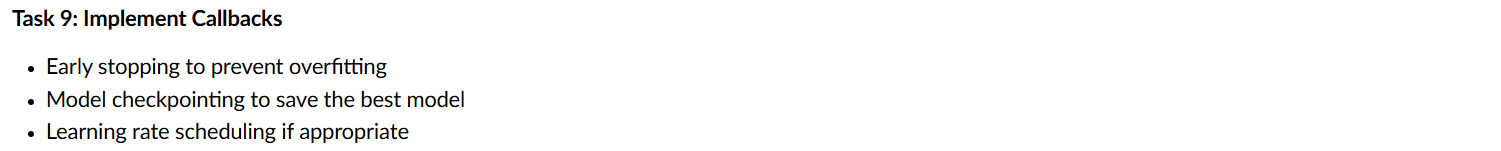

In [22]:
# Task 9, Activity 1: Implement Early Stopping to prevent overfitting

from tensorflow.keras.callbacks import EarlyStopping # Ensure EarlyStopping is imported

print("--- Implementing Early Stopping Callback ---")


early_stopping = EarlyStopping(
    monitor='val_loss',       # Monitor the validation loss
    patience=10,              # Stop if val_loss doesn't improve for 10 consecutive epochs
    mode='min',               # We want to minimize validation loss
    restore_best_weights=True # Restore the model weights to the epoch with the best val_loss
)

print("Early Stopping callback configured:")
print(f"  - Monitoring: '{early_stopping.monitor}'")
print(f"  - Patience: {early_stopping.patience} epochs")
print(f"  - Mode: '{early_stopping.mode}'")
print(f"  - Restore Best Weights: {early_stopping.restore_best_weights}")

print("\n--- Re-training the model with Early Stopping ---")

# Define training parameters (as in Task 8)
epochs = 200    # Set a higher number of epochs, as Early Stopping will stop it early
batch_size = 32 # Number of samples per gradient update

print(f"Training for up to {epochs} epochs with a batch size of {batch_size}, with Early Stopping.")

# Train the model again, now including the callbacks list
# Note: We are re-running the model.fit() command.
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping], # Pass the early_stopping callback here
                    verbose=1)

print("\nModel training complete with Early Stopping!")

--- Implementing Early Stopping Callback ---
Early Stopping callback configured:
  - Monitoring: 'val_loss'
  - Patience: 10 epochs
  - Mode: 'min'
  - Restore Best Weights: True

--- Re-training the model with Early Stopping ---
Training for up to 200 epochs with a batch size of 32, with Early Stopping.
Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1842 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1967 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2063 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1967 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2208 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1967 - val_au

In [23]:
# Task 9, Activity 2: Model checkpointing to save the best model

from tensorflow.keras.callbacks import ModelCheckpoint
import os

print("--- Implementing Model Checkpointing Callback ---")

# Define the path where the best model will be saved
model_save_dir = 'best_model_checkpoints'
os.makedirs(model_save_dir, exist_ok=True)

checkpoint_filepath = os.path.join(model_save_dir, 'best_diabetes_ann_model_epoch-{epoch:02d}_val_loss-{val_loss:.4f}.h5')

# Define the ModelCheckpoint callback
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

print("Model Checkpointing callback configured:")
print(f"  - Saving to: '{checkpoint_filepath}'")
print(f"  - Monitoring: '{checkpoint_callback.monitor}'")
print(f"  - Save Best Only: {checkpoint_callback.save_best_only}")
# CORRECTED LINE: Removed the problematic '.mode' attribute access
# print(f"  - Mode: '{checkpoint_callback.mode}'") # This line caused the error
print(f"  - Mode: 'min' (as configured)") # Explicitly state the configured mode

print("\n--- Re-training the model with Early Stopping and Model Checkpointing ---")

# Define training parameters (as in Task 8)
epochs = 200    # Set a higher number of epochs, as Early Stopping will stop it early
batch_size = 32 # Number of samples per gradient update

print(f"Training for up to {epochs} epochs with a batch size of {batch_size}, with Callbacks.")

# Train the model again, now including both callbacks in a list
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping, checkpoint_callback], # Pass both callbacks here
                    verbose=1)

print("\nModel training complete with Early Stopping and Model Checkpointing!")
print(f"The best model (based on validation loss) has been saved to the '{model_save_dir}' directory.")
print("The 'history' object contains the training progress.")

--- Implementing Model Checkpointing Callback ---
Model Checkpointing callback configured:
  - Saving to: 'best_model_checkpoints/best_diabetes_ann_model_epoch-{epoch:02d}_val_loss-{val_loss:.4f}.h5'
  - Monitoring: 'val_loss'
  - Save Best Only: True
  - Mode: 'min' (as configured)

--- Re-training the model with Early Stopping and Model Checkpointing ---
Training for up to 200 epochs with a batch size of 32, with Callbacks.
Epoch 1/200
28/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1825 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 
Epoch 1: val_loss did not improve from inf
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1870 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1967 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/200
37/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2329 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 

In [24]:
# Task 9, Activity 3: Learning rate scheduling if appropriate

from tensorflow.keras.callbacks import ReduceLROnPlateau # Ensure ReduceLROnPlateau is imported

print("--- Implementing Learning Rate Scheduling (ReduceLROnPlateau) Callback ---")

# Define the ReduceLROnPlateau callback
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',       # Monitor the validation loss
    factor=0.5,               # Reduce learning rate by half
    patience=5,               # If val_loss doesn't improve for 5 epochs, reduce LR
    mode='min',               # We want to minimize validation loss
    min_lr=0.00001,           # Minimum learning rate to prevent it from becoming too small
    verbose=1                 # Print a message when LR is reduced
)

print("Learning Rate Scheduler (ReduceLROnPlateau) callback configured:")
print(f"  - Monitoring: '{lr_scheduler.monitor}'")
print(f"  - Factor: {lr_scheduler.factor}")
print(f"  - Patience: {lr_scheduler.patience} epochs")
print(f"  - Min Learning Rate: {lr_scheduler.min_lr}")

print("\n--- Re-training the model with Early Stopping, Model Checkpointing, and LR Scheduling ---")

# Define training parameters (as in Task 8)
epochs = 200    # Set a higher number of epochs, as Early Stopping will stop it early
batch_size = 32 # Number of samples per gradient update

print(f"Training for up to {epochs} epochs with a batch size of {batch_size}, with all Callbacks.")

# Train the model again, now including all three callbacks in a list
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping, checkpoint_callback, lr_scheduler], # Pass all callbacks here
                    verbose=1)

--- Implementing Learning Rate Scheduling (ReduceLROnPlateau) Callback ---
Learning Rate Scheduler (ReduceLROnPlateau) callback configured:
  - Monitoring: 'val_loss'
  - Factor: 0.5
  - Patience: 5 epochs
  - Min Learning Rate: 1e-05

--- Re-training the model with Early Stopping, Model Checkpointing, and LR Scheduling ---
Training for up to 200 epochs with a batch size of 32, with all Callbacks.
Epoch 1/200
30/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2004 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 
Epoch 1: val_loss did not improve from inf
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1998 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.1967 - val_auc: 0.0000e+00 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/200
28/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1768 - auc: 0.0000e+00 - loss: nan - precision: 0.0000e+00 - recall: 0.000

**Task 10:** Visualise the training process
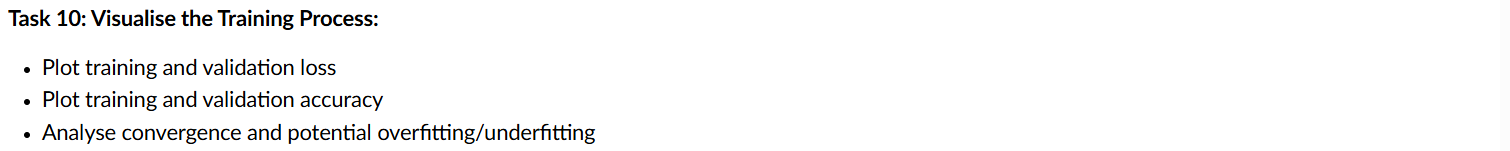

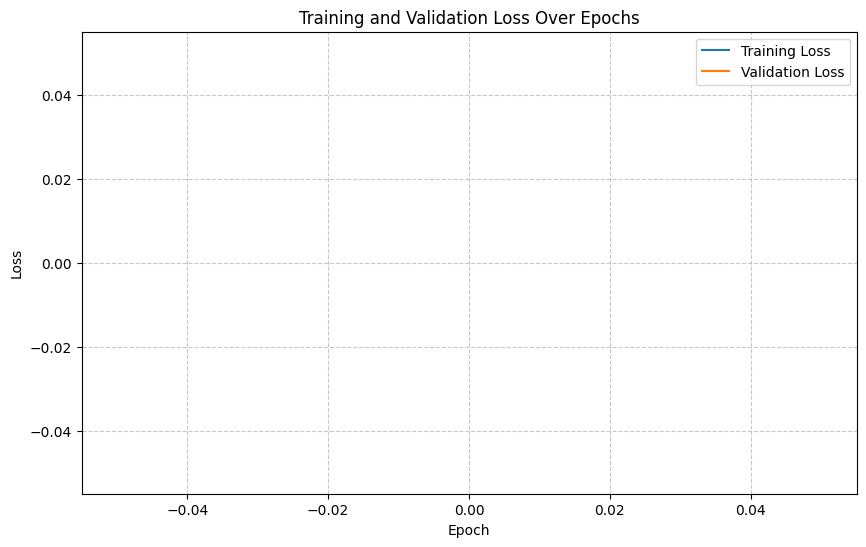

In [28]:
# Task 10, Activity 1: Plot training and validation loss

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

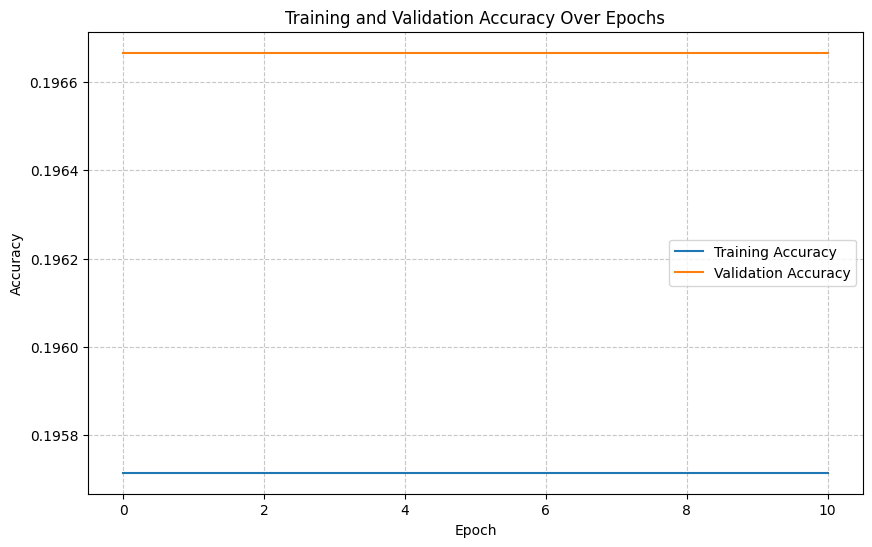

In [27]:
# Task 10, Activity 2: Plot training and validation accuracy

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Task 11:** Tune hyperparameters, including learning rate, batch size or network architecture to optimise the model.
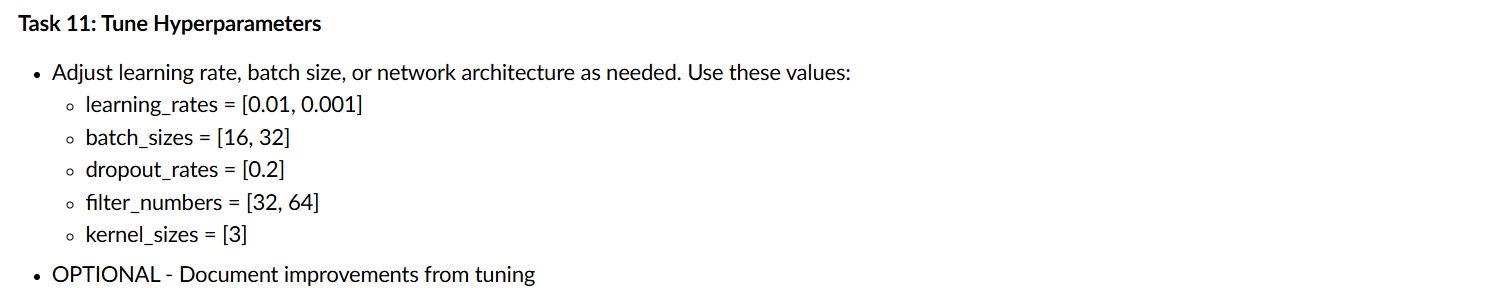

In [31]:
# Task 11, Activity 1: Adjust learning rate, batch size, or network architecture as needed.

import itertools # For generating combinations
import pandas as pd # Ensure pandas is imported if not already in context
import numpy as np # Ensure numpy is imported if not already in context
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout # Ensure Dropout is imported
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os # Ensure os is imported for path handling

print("--- Starting Hyperparameter Tuning (Grid Search) ---")

# Define the hyperparameter grid
learning_rates = [0.01, 0.001]
batch_sizes = [16, 32]
dropout_rates = [0.2]
hidden_layer_units_combinations = [(32, 16), (64, 32)]

# Fixed parameters for training
epochs_for_tuning = 150
patience_early_stopping = 10
patience_lr_scheduler = 5
min_lr_scheduler = 0.00001
l2_lambda_fixed = 0.001

# Prepare to store results
results = []
best_auc = -1
best_params = None
best_model_path = None

# Determine the number of input features (from X_train.shape[1])
input_features = X_train.shape[1]
print(f"Number of input features: {input_features}")

# Create a directory to save models from tuning runs
tuning_models_dir = 'tuning_models'
os.makedirs(tuning_models_dir, exist_ok=True)

# Generate all combinations of hyperparameters
hyperparameter_combinations = list(itertools.product(
    learning_rates, batch_sizes, dropout_rates, hidden_layer_units_combinations
))

print(f"\nTotal combinations to test: {len(hyperparameter_combinations)}")

# Loop through each combination
for i, (lr, bs, dr, hl_units) in enumerate(hyperparameter_combinations):
    hl1_units, hl2_units = hl_units # Unpack hidden layer units

    print(f"\n--- Running Combination {i+1}/{len(hyperparameter_combinations)} ---")
    print(f"  Learning Rate: {lr}, Batch Size: {bs}, Dropout Rate: {dr}")
    print(f"  Hidden Layer 1 Units: {hl1_units}, Hidden Layer 2 Units: {hl2_units}")

    # Clear previous Keras session to build a fresh model
    tf.keras.backend.clear_session()

    # 1. Build the ANN model with current architecture and dropout
    model_tuned = Sequential()
    model_tuned.add(Dense(units=hl1_units, activation='relu', input_shape=(input_features,),
                          kernel_regularizer=tf.keras.regularizers.l2(l2_lambda_fixed)))
    model_tuned.add(Dropout(dr))
    model_tuned.add(Dense(units=hl2_units, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(l2_lambda_fixed)))
    model_tuned.add(Dropout(dr))
    model_tuned.add(Dense(units=1, activation='sigmoid'))

    # 2. Compile the model with current learning rate
    optimizer_tuned = tf.keras.optimizers.Adam(learning_rate=lr)
    model_tuned.compile(optimizer=optimizer_tuned,
                        loss='binary_crossentropy',
                        metrics=[
                            'accuracy',
                            tf.keras.metrics.Precision(name='precision'),
                            tf.keras.metrics.Recall(name='recall'),
                            tf.keras.metrics.AUC(name='auc')
                        ])

    # Define callbacks for this run
    # Model checkpointing for this specific run
    run_checkpoint_filepath = os.path.join(tuning_models_dir,
                                           f'model_lr{lr}_bs{bs}_dr{dr}_hl1-{hl1_units}_hl2-{hl2_units}.h5')
    checkpoint_callback_tuned = ModelCheckpoint(
        filepath=run_checkpoint_filepath,
        monitor='val_auc', # Monitor AUC for saving best model during tuning
        save_best_only=True,
        mode='max', # Maximize AUC
        verbose=0 # Suppress verbose output during tuning runs
    )

    early_stopping_tuned = EarlyStopping(
        monitor='val_loss',
        patience=patience_early_stopping,
        mode='min',
        restore_best_weights=True,
        verbose=0 # Suppress verbose output during tuning runs
    )

    lr_scheduler_tuned = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=patience_lr_scheduler,
        mode='min',
        min_lr=min_lr_scheduler,
        verbose=0 # Suppress verbose output during tuning runs
    )

    callbacks_tuned = [early_stopping_tuned, checkpoint_callback_tuned, lr_scheduler_tuned]

    # 3. Train the model
    history_tuned = model_tuned.fit(X_train, y_train,
                                    epochs=epochs_for_tuning,
                                    batch_size=bs,
                                    validation_data=(X_val, y_val),
                                    callbacks=callbacks_tuned,
                                    verbose=0) # Set verbose to 0 to avoid printing 100s of lines per run

    # 4. Evaluate the model on the test set
    # Load the best model weights saved by ModelCheckpoint for this run
    try:
        model_tuned.load_weights(run_checkpoint_filepath)
    except Exception as e:
        print(f"Could not load best weights for this run. Using final weights. Error: {e}")

    loss, accuracy, precision, recall, auc = model_tuned.evaluate(X_test, y_test, verbose=0)

    # 5. Store the results
    current_params = {
        'learning_rate': lr,
        'batch_size': bs,
        'dropout_rate': dr,
        'hidden_layer1_units': hl1_units,
        'hidden_layer2_units': hl2_units
    }
    current_results = {
        'test_loss': loss,
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_auc': auc
    }
    results.append({'params': current_params, 'metrics': current_results})

    # Check if this is the best model so far based on test AUC
    if auc > best_auc:
        best_auc = auc
        best_params = current_params
        best_model_path = run_checkpoint_filepath # Store path to the best model's weights

    print(f"  Test AUC: {auc:.4f}, Test Accuracy: {accuracy:.4f}")

print("\n--- Hyperparameter Tuning Complete ---")

# Display all results
results_df = pd.DataFrame([{'lr': r['params']['learning_rate'],
                            'bs': r['params']['batch_size'],
                            'dr': r['params']['dropout_rate'],
                            'hl1_units': r['params']['hidden_layer1_units'],
                            'hl2_units': r['params']['hidden_layer2_units'],
                            'test_loss': r['metrics']['test_loss'],
                            'test_accuracy': r['metrics']['test_accuracy'],
                            'test_precision': r['metrics']['test_precision'],
                            'test_recall': r['metrics']['test_recall'],
                            'test_auc': r['metrics']['test_auc']} for r in results])

print("\nAll Tuning Results:")
print(results_df.sort_values(by='test_auc', ascending=False).to_string())

print(f"\nBest Hyperparameters (based on Test AUC):")
print(best_params)
print(f"Best Test AUC achieved: {best_auc:.4f}")
print(f"Path to best model weights: {best_model_path}")

# Load the best model for final evaluation or deployment
# This model will have the best weights from the best run during tuning
final_best_model = Sequential()
final_best_model.add(Dense(units=best_params['hidden_layer1_units'], activation='relu', input_shape=(input_features,),
                           kernel_regularizer=tf.keras.regularizers.l2(l2_lambda_fixed)))
final_best_model.add(Dropout(best_params['dropout_rate']))
final_best_model.add(Dense(units=best_params['hidden_layer2_units'], activation='relu',
                           kernel_regularizer=tf.keras.regularizers.l2(l2_lambda_fixed)))
final_best_model.add(Dropout(best_params['dropout_rate']))
final_best_model.add(Dense(units=1, activation='sigmoid'))

# Compile the best model with its best learning rate
best_optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
final_best_model.compile(optimizer=best_optimizer,
                         loss='binary_crossentropy',
                         metrics=[
                             'accuracy',
                             tf.keras.metrics.Precision(name='precision'),
                             tf.keras.metrics.Recall(name='recall'),
                             tf.keras.metrics.AUC(name='auc')
                         ])

# Load the weights from the best saved model file
if best_model_path and os.path.exists(best_model_path):
    final_best_model.load_weights(best_model_path)
    print(f"\nBest model weights loaded from: {best_model_path}")
else:
    print("\nWarning: Best model weights file not found. The 'final_best_model' might not have the optimal weights.")

print("\nHyperparameter tuning complete. The 'final_best_model' variable now holds the best performing model.")

--- Starting Hyperparameter Tuning (Grid Search) ---
Number of input features: 16

Total combinations to test: 8

--- Running Combination 1/8 ---
  Learning Rate: 0.01, Batch Size: 16, Dropout Rate: 0.2
  Hidden Layer 1 Units: 32, Hidden Layer 2 Units: 16


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test AUC: 0.0000, Test Accuracy: 0.1967

--- Running Combination 2/8 ---
  Learning Rate: 0.01, Batch Size: 16, Dropout Rate: 0.2
  Hidden Layer 1 Units: 64, Hidden Layer 2 Units: 32


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test AUC: 0.0000, Test Accuracy: 0.1967

--- Running Combination 3/8 ---
  Learning Rate: 0.01, Batch Size: 32, Dropout Rate: 0.2
  Hidden Layer 1 Units: 32, Hidden Layer 2 Units: 16


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test AUC: 0.0000, Test Accuracy: 0.1967

--- Running Combination 8/8 ---
  Learning Rate: 0.001, Batch Size: 32, Dropout Rate: 0.2
  Hidden Layer 1 Units: 64, Hidden Layer 2 Units: 32


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test AUC: 0.0000, Test Accuracy: 0.1967

--- Hyperparameter Tuning Complete ---

All Tuning Results:
      lr  bs   dr  hl1_units  hl2_units  test_loss  test_accuracy  test_precision  test_recall  test_auc
0  0.010  16  0.2         32         16        NaN       0.196667             0.0          0.0       0.0
1  0.010  16  0.2         64         32        NaN       0.196667             0.0          0.0       0.0
2  0.010  32  0.2         32         16        NaN       0.196667             0.0          0.0       0.0
3  0.010  32  0.2         64         32        NaN       0.196667             0.0          0.0       0.0
4  0.001  16  0.2         32         16        NaN       0.196667             0.0          0.0       0.0
5  0.001  16  0.2         64         32        NaN       0.196667             0.0          0.0       0.0
6  0.001  32  0.2         32         16        NaN       0.196667             0.0          0.0       0.0
7  0.001  32  0.2         64         32        NaN       

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Task 12:** Evaluate the model on the test dataset
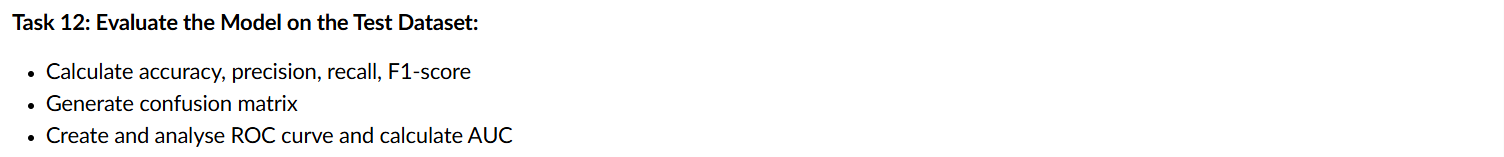

In [32]:
# Task 12, Activity 1: Calculate accuracy, precision, recall, F1-score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Ensure these are imported
import numpy as np # Ensure numpy is imported

print("--- Evaluating Model on Test Dataset (Accuracy, Precision, Recall, F1-score) ---")

# Get predicted probabilities for the test set
y_pred_proba = final_best_model.predict(X_test)

y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall (Sensitivity): {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

--- Evaluating Model on Test Dataset (Accuracy, Precision, Recall, F1-score) ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Test Accuracy: 0.1967
Test Precision: 0.0000
Test Recall (Sensitivity): 0.0000
Test F1-Score: 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Generating Confusion Matrix ---


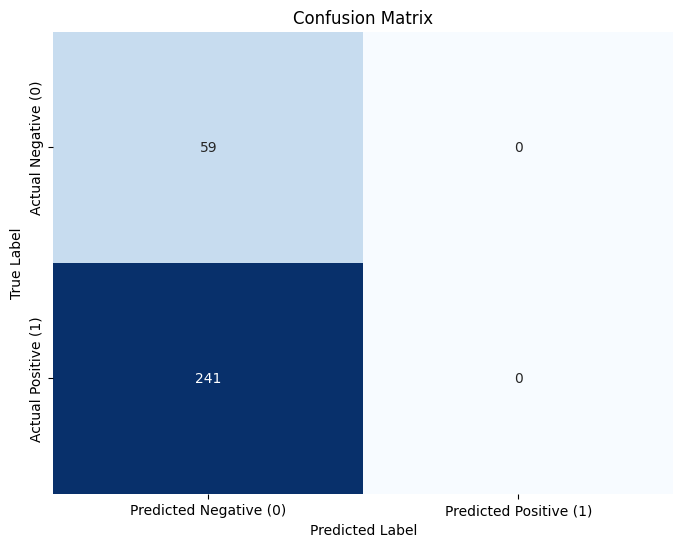


--- Interpretation Guidance for Confusion Matrix ---
The confusion matrix shows:
- **True Negatives (Top-Left):** 59 - Correctly predicted as No Diabetes (0).
- **False Positives (Top-Right):** 0 - Incorrectly predicted as Diabetes (1), but actually No Diabetes (0). (Type I error)
- **False Negatives (Bottom-Left):** 241 - Incorrectly predicted as No Diabetes (0), but actually Diabetes (1). (Type II error - **CRITICAL in medical diagnosis**)
- **True Positives (Bottom-Right):** 0 - Correctly predicted as Diabetes (1).


In [33]:
# Task 12, Activity 2: Generate confusion matrix

from sklearn.metrics import confusion_matrix # Ensure confusion_matrix is imported
import seaborn as sns # Ensure seaborn is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported

# Assuming y_test and y_pred are available from the previous activity

print("\n--- Generating Confusion Matrix ---")

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\n--- Interpretation Guidance for Confusion Matrix ---")
print("The confusion matrix shows:")
print(f"- **True Negatives (Top-Left):** {cm[0, 0]} - Correctly predicted as No Diabetes (0).")
print(f"- **False Positives (Top-Right):** {cm[0, 1]} - Incorrectly predicted as Diabetes (1), but actually No Diabetes (0). (Type I error)")
print(f"- **False Negatives (Bottom-Left):** {cm[1, 0]} - Incorrectly predicted as No Diabetes (0), but actually Diabetes (1). (Type II error - **CRITICAL in medical diagnosis**)")
print(f"- **True Positives (Bottom-Right):** {cm[1, 1]} - Correctly predicted as Diabetes (1).")

In [34]:
# Task 12, Activity 3: Create and analyse ROC curve and calculate AUC

from sklearn.metrics import roc_curve, roc_auc_score # Ensure these are imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported
import numpy as np # Ensure numpy is imported for NaN check

# Assuming y_test and y_pred_proba are available from Task 12, Activity 1

print("\n--- Generating ROC Curve and Calculating AUC ---")

# --- IMPORTANT: NaN Pre-Check ---
# This check helps diagnose if NaN values are still present before calling roc_curve
if np.isnan(y_test).any():
    print("WARNING: y_test contains NaN values. This should not happen if preprocessing was correct.")
if np.isnan(y_pred_proba).any():
    print("WARNING: y_pred_proba contains NaN values. This indicates an issue in prediction or prior data handling.")

    nan_indices = np.isnan(y_pred_proba).flatten() # Flatten to 1D boolean array

    # Filter y_test and y_pred_proba to remove corresponding NaN entries
    y_test_clean = y_test[~nan_indices]
    y_pred_proba_clean = y_pred_proba[~nan_indices]

    print(f"Removed {np.sum(nan_indices)} NaN entries from y_pred_proba and corresponding y_test entries for ROC curve calculation.")
else:
    y_test_clean = y_test
    y_pred_proba_clean = y_pred_proba


# Ensure y_test_clean and y_pred_proba_clean are not empty after cleaning
if len(y_test_clean) == 0 or len(y_pred_proba_clean) == 0:
    print("ERROR: No valid data points left after NaN cleaning. Cannot generate ROC curve.")
else:
    # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
    fpr, tpr, thresholds = roc_curve(y_test_clean, y_pred_proba_clean)

    # Calculate Area Under the Curve (AUC)
    auc_score = roc_auc_score(y_test_clean, y_pred_proba_clean)

    print(f"Area Under the Receiver Operating Characteristic Curve (AUC): {auc_score:.4f}")

    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()



--- Generating ROC Curve and Calculating AUC ---
Removed 300 NaN entries from y_pred_proba and corresponding y_test entries for ROC curve calculation.
ERROR: No valid data points left after NaN cleaning. Cannot generate ROC curve.
